<a href="https://colab.research.google.com/github/harishmuh/Computer_Vision_study/blob/main/Object_detection_with_YOLOv8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Object detection on static images with YOLOv8**

## **Introduction**

Previously, we have conducted object detection with YOLOv3 model in this [notebook](https://github.com/harishmuh/Computer_Vision_study/blob/main/Yolov3_static_images.ipynb). Now, we will do the same thing but with the more upgraded version YOLOv8.

**Initial setup**

We will start by installing the YOLO framework.

In [3]:
# Installing additional library
#!pip install ultralytics #Remove the ('#') to install

In [2]:
# Importing libraries
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import urllib.request
import numpy as np
from google.colab.patches import cv2_imshow

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


We will use `yolo8n.pt` as It is the smallest and fastest variant in the YOLOv8 object detection model family. This model file is designed for applications where computational power is limited. So, this model prioritizes speed over accuracy.

The YOLOv8 nano model is pretrained on the COCO dataset, developed by [ultralytics](https://platform.ultralytics.com/)

**YOLOv8 Model preparation**

In [4]:
# Preparing YOLOv8

# Downloading YOLOv8 starter files
model = YOLO('yolov8n.pt')

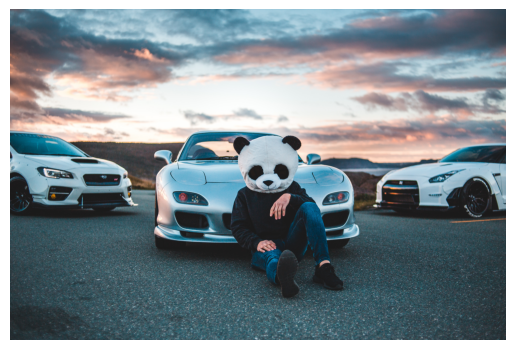

In [5]:
# Attaching the input image

# Image link
url = 'https://github.com/harishmuh/Deep-Learning_study/blob/main/data/DeepCV/person-car.jpg?raw=true'

# Download and open the image
with urllib.request.urlopen(url) as f:
    input_img = Image.open(f)

# Convert PIL Image to NumPy array for OpenCV compatibility
input_img = np.array(input_img)

# Displaying the original image
plt.axis('off')
plt.imshow(input_img, cmap='gray')
plt.show()

## **Object detection with YOLO**

Now, lets implement the object detection with YOLOv8.


0: 448x640 3 cars, 1 teddy bear, 320.5ms
Speed: 28.2ms preprocess, 320.5ms inference, 34.8ms postprocess per image at shape (1, 3, 448, 640)


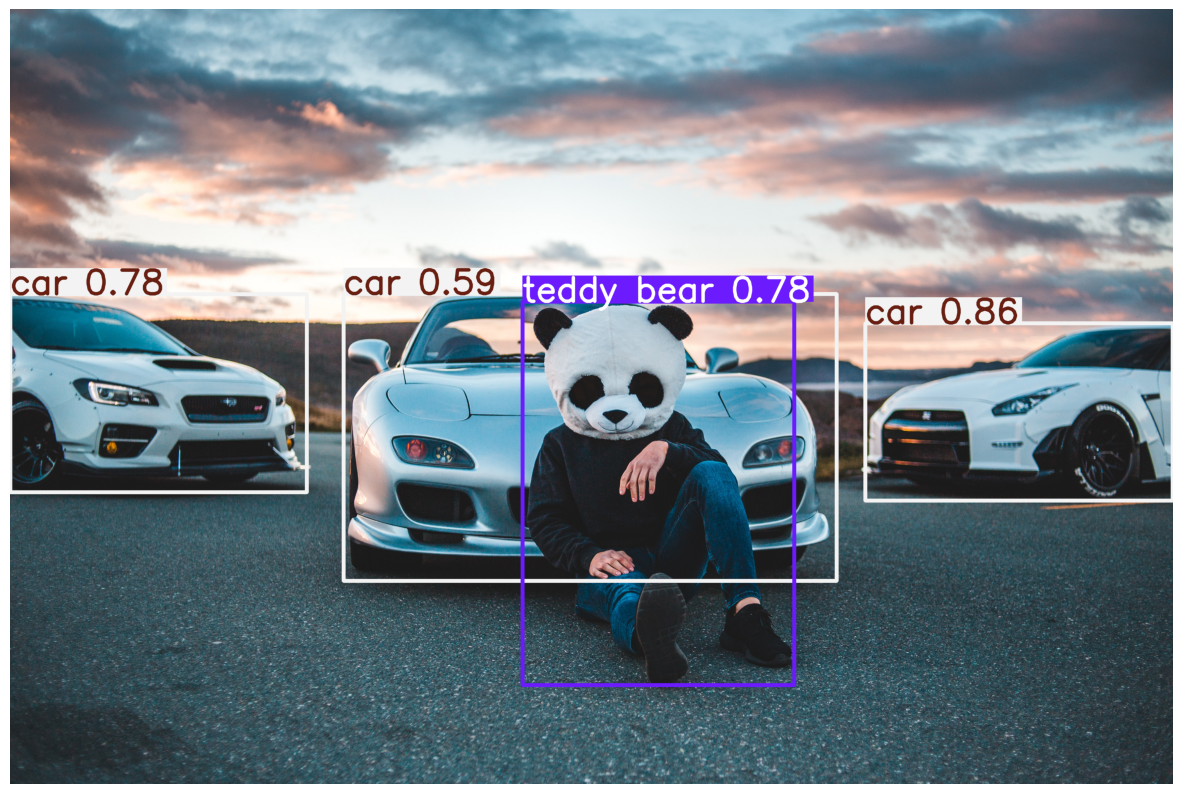

In [6]:
# Conduting object detection (YOLOv8) in input image
prediction = model.predict(input_img, agnostic_nms=True)
result = prediction[0]

# plot detection result on the input image
img_detect = result.plot(line_width=15)

# Displaying the detected image
plt.figure(figsize=(15,15))
plt.axis('off')
plt.imshow(img_detect)
plt.show()

If we compare, with the previous version of YOLOv3 (as the image below),the accuracy score seems lower, but we get better prediction (practically) as more objects are getting predicted in the YOLOv8 (4 objects) than the YOLOv3 (3 objects).



![image](https://github.com/harishmuh/Computer_Vision_study/blob/main/data/images/detect%20-%20person%20car.PNG?raw=true)
The output of YOLOv3 (the code can be seen in this [link](https://github.com/harishmuh/Computer_Vision_study/blob/main/Yolov3_static_images.ipynb)

Now, lets do it with an image with more objects.

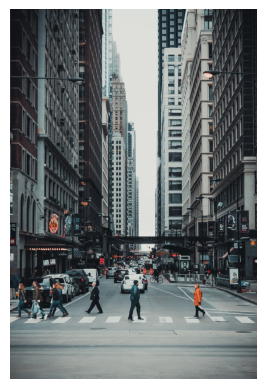

In [9]:
# Attaching the second input image

# Image link
url1 = 'https://github.com/harishmuh/Deep-Learning_study/blob/main/data/DeepCV/city_traffic.jpg?raw=true'

# Download and open the image
with urllib.request.urlopen(url1) as f:
    city_traffic_img = Image.open(f)

# Convert PIL Image to NumPy array for OpenCV compatibility
city_traffic_img = np.array(city_traffic_img)

# Displaying the original image
plt.axis('off')
plt.imshow(city_traffic_img, cmap='gray')
plt.show()


0: 640x448 6 persons, 5 cars, 120.7ms
Speed: 4.0ms preprocess, 120.7ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 448)


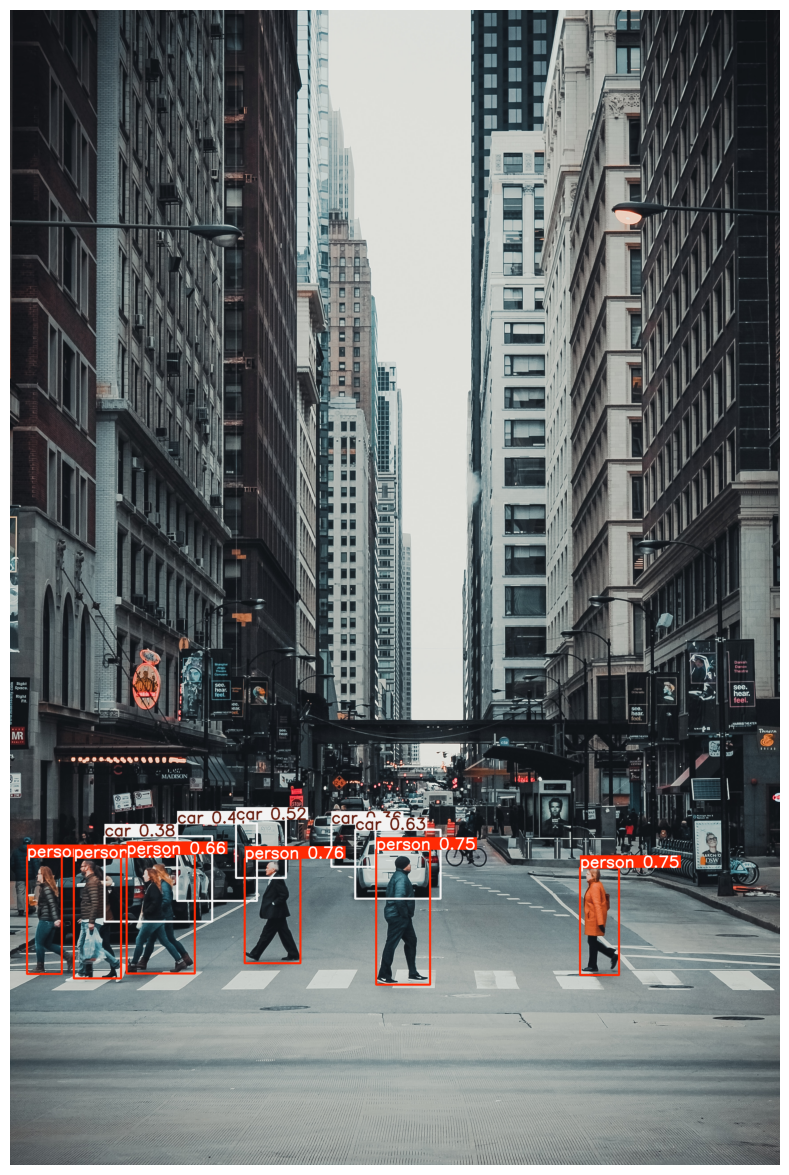

In [11]:
# Conduting object detection in input image
prediction_1 = model.predict(city_traffic_img, agnostic_nms=True)
result_1 = prediction_1[0]

# plot detection result on the input image
img_detect_1 = result_1.plot(line_width=7)

# Displaying the detected image
plt.figure(figsize=(15,15))
plt.axis('off')
plt.imshow(img_detect_1)
plt.show()

We can see the YOLOv8 model can detect 6 person and 5 images in the image.

## **Conclusion**

In this notebook, we successfully performed object detection on static images using the YOLOv8 nano model. We observed its capability to detect multiple objects in an image, including cars, persons, and a teddy bear. The YOLOv8 model demonstrates improved practical prediction by detecting more objects compared to its predecessor, YOLOv3, highlighting its efficiency and accuracy for object detection tasks even with a smaller, faster variant.